<a href="https://colab.research.google.com/github/rezaaf-zk/Regresi_Linear/blob/main/Linear%20Sederhana_Studi_kasus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [20]:
data = {
    'Jam_belajar': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nilai_ujian': [45, 50, 55, 62, 68, 75, 80, 85, 92, 98]
}
df = pd.DataFrame(data)
print(df)

   Jam_belajar  Nilai_ujian
0            1           45
1            2           50
2            3           55
3            4           62
4            5           68
5            6           75
6            7           80
7            8           85
8            9           92
9           10           98


Berdasarkan dataset ini, terlihat adanya hubungan linear positif yang kuat antara waktu belajar dan hasil ujian. Setiap penambahan satu jam belajar secara konsisten meningkatkan skor ujian sekitar 5-7 poin. Model regresi linear sederhana ini sangat efektif digunakan di sini karena datanya tidak memiliki banyak fluktuasi (noise) dan polanya membentuk garis lurus yang jelas. Secara intuitif, model ini memvalidasi bahwa semakin besar usaha (input), semakin besar pula hasil (output) yang didapatkan secara proporsional

In [3]:
x = df[['Jam_belajar']]
y = df['Nilai_ujian']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

print("Intercept (a):", model.intercept_)
print("Coefisien (b):", model.coef_[0])

Intercept (a): 38.37931034482759
Coefisien (b): 5.931034482758621


In [6]:
y_pred = model.predict(x_test)

print("Data Testing:")
print(x_test)
print("Nilai Asli:", y_test.values)
print("Nilai Prediksi:", y_pred)

Data Testing:
   jam_belajar
8            9
1            2
Nilai Asli: [92 50]
Nilai Prediksi: [91.75862069 50.24137931]


In [7]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.24137931034482563
MSE: 0.05826397146254365
RMSE: 0.24137931034482563


In [22]:
prediction = model.predict([[7.5]])
print("Prediksi untuk 7.5 jam belajar:", prediction[0])

Prediksi untuk 7.5 jam belajar: 82.86206896551724


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


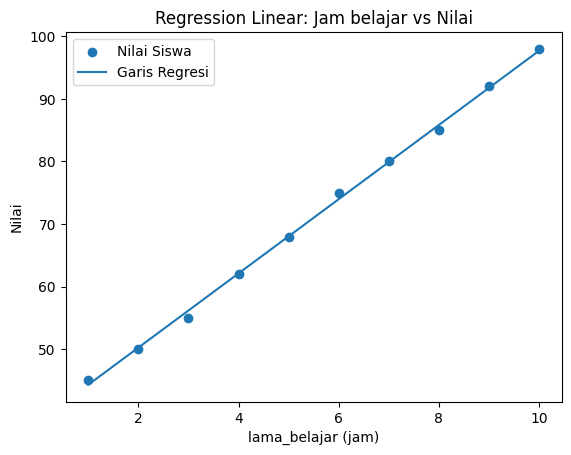

In [21]:
plt.scatter(x, y, label="Nilai Siswa")
plt.plot(x, model.predict(x), label="Garis Regresi")
plt.xlabel("lama_belajar (jam)")
plt.ylabel("Nilai")
plt.title("Regression Linear: Jam belajar vs Nilai")
plt.legend()
plt.show()
